# Pneumonia Detection

<font color='green'> <br>
    ***********************************************************************************************  <br><br>
    &emsp; Deep Learning Project:&emsp; Multi-class classification <br><br>
    &emsp; Author:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&nbsp; Uttara Naidu <br><br>
    &emsp; Date:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; 10/02/2026 <br><br>
    &emsp; Version: &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;v0.1 (WIP) <br><br>
    &emsp; Description:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; Implements a U-NET model for multi-class classification <br><br>
    ***********************************************************************************************  <br>
 </font>

<font color='blue'> NOTE: This is an initial draft version. Code clean-up and optimizations will follow soon. </font>

The project demonstates a classification model based on U-NET architecture (Ronneberger,2015) with skip connections. This architecture is based on the foundational Encoder-Decoder principle, enhanced with feature concatenations.
A general flow is explained below:
- an image's extracted features, post convolutions, are saved during downsampling its spatial dimensions
- downsampling continues until the model reaches its bottleneck i.e. its most compressed version of the input
- upsampling begins after this stage where the features saved in first step are concatenated with the upsampled image

This approach prevents the loss of details in an image by saving its original features after convolutions downsampling it, followed by a subsequent upsampling. 

Based on this architecture, in 2021 Wu et. al. proposed a ULNet architecture that has an additional 'L' element where the upsampling is followed by another round of downsampling before being fed to two Dense layers. Due to hardware limitation, the model architecture in this project only implements U-NET model using skip connections and Batch normalization layers.

The dataset is downloaded from Kaggle - 'COVID-19 Radiography Database'. Available at: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database.

**References:**

Ronneberger, O., Fischer, P., Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. 
In: Navab, N., Hornegger, J., Wells, W., Frangi, A. (eds) Medical Image Computing and Computer-Assisted Intervention – MICCAI 2015. MICCAI 2015. 
Lecture Notes in Computer Science(), vol 9351. Springer, Cham. https://doi.org/10.1007/978-3-319-24574-4_28

Wu, T. et al. (2021) “ULNet for the detection of coronavirus (COVID-19) from chest X-ray images,” Computers in biology and medicine, 137. Available at: https://doi.org/10.1016/j.compbiomed.2021.104834.

M.E.H. Chowdhury, T. Rahman, A. Khandakar, R. Mazhar, M.A. Kadir, Z.B. Mahbub, K.R. Islam, M.S. Khan, A. Iqbal, N. Al-Emadi, M.B.I. Reaz, M. T. Islam, “Can AI help in screening Viral and COVID-19 pneumonia?” IEEE Access, Vol. 8, 2020, pp. 132665 - 132676.

Rahman, T., Khandakar, A., Qiblawey, Y., Tahir, A., Kiranyaz, S., Kashem, S.B.A., Islam, M.T., Maadeed, S.A., Zughaier, S.M., Khan, M.S. and Chowdhury, M.E., 2020. Exploring the Effect of Image Enhancement Techniques on COVID-19 Detection using Chest X-ray Images.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys, warnings, json
warnings.filterwarnings('ignore')
from collections import defaultdict
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve, auc

In [2]:
""" 
    Download dataset 'covid19-radiography-database' from Kaggle
"""

try:
    with open("config.json") as f:
        js = f.read()
        json_obj = json.loads(js)

    project_path = json_obj['project_directory']

    sys.path.append(project_path)
    from scripts.data_loader import load_dataset, get_classes, get_data
    from scripts.data_preparation import prepare_dataset, one_hot_encoding, display_unique_labels
    from scripts.data_pipeline_operations import process_data_pipeline, batch_dataset, augment_data, preprocess_data_pipeline, create_ds
    from scripts.model_builder import conv_block, build_decoder, build_encoder,callbacks

except:
    raise Exception('Please configure the path to project directory in the file "config.json". If path is correct, then check if all imports are valid.')


2026-02-04 18:20:35.967386: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-02-04 18:20:35.967411: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2026-02-04 18:20:35.967414: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 25.92 GB
I0000 00:00:1770225635.967426 6366889 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770225635.967445 6366889 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
# Loading dataset from Kaggle
 
PROJ_DIR = project_path
dataset_download_dir = f'{PROJ_DIR}/data'
ROOT_DIR = load_dataset('tawsifurrahman/covid19-radiography-database', dataset_download_dir)

Dataset downloaded successfully at: /Users/samy/uttara/pneumonia_detection/data/datasets/tawsifurrahman/covid19-radiography-database/versions/5
The root directory:  /Users/samy/uttara/pneumonia_detection/data/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset


In [4]:
# Extracting class names from dataset

classes = get_classes(ROOT_DIR)

Retrieveing files from:  /Users/samy/uttara/pneumonia_detection/data/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset
Extracting class names ...
There are 4 available classes:

 1. COVID 
    |-- images
    |-- masks

 2. Lung_Opacity 
    |-- images
    |-- masks

 3. Normal 
    |-- images
    |-- masks

 4. Viral Pneumonia 
    |-- images
    |-- masks


# Exploratory data analysis

In [5]:
""" 
    This part deals with below aspects of data points - i.e. images:
        1. summarizing data from each class
        2. total number of images in each class
        2. total number of images in each sub-class i.e. X-rays and Masks
"""

count_dict = defaultdict(dict)


for key in classes:
    xray, mask = classes[key]
    count_dict[key]['X-rays'] = len(os.listdir(xray))
    count_dict[key]['Masks'] = len(os.listdir(mask))



count_df = pd.DataFrame(count_dict)
count_df['TOTAL']= count_df.sum(axis=1)
count_df

,COVID,LUNG_OPACITY,NORMAL,VIRAL_PNEUMONIA,TOTAL
X-rays,3616,6012,10192,1345,21165
Masks,3616,6012,10192,1345,21165


([<matplotlib.patches.Wedge at 0x30b57e050>,
 [Text(0.9453209372067657, 0.5624662884818274, 'COVID'),
  Text(-0.42334543330748536, 1.0152726944509527, 'LUNG_OPACITY'),
  Text(-0.3682068593232714, -1.036544118090153, 'NORMAL'),
  Text(1.0781511930471523, -0.21815133492830643, 'VIRAL_PNEUMONIA')],
 [Text(0.5156296021127812, 0.3067997937173604, '17%'),
  Text(-0.23091569089499198, 0.553785106064156, '28%'),
  Text(-0.20084010508542074, -0.565387700776447, '48%'),
  Text(0.5880824689348103, -0.11899163723362167, '6%')])

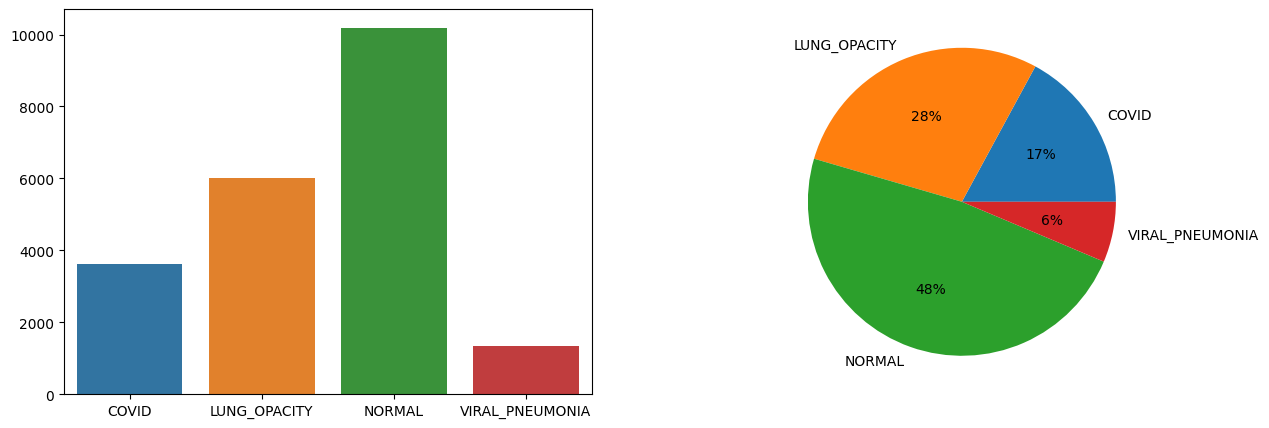

In [6]:
# Visualize data count

fig, ax =  plt.subplots(1,2,figsize=(15,5))
sns.barplot(count_df.iloc[:,0:4],ax=ax[0])
plt.pie(count_df.iloc[0,0:4],labels=list(classes.keys()),autopct='%.0f%%')


In [7]:
""" 
    Perform preliminary checks on a small sample of image data, like,
        1. check image dimensionality
        2. verify colour space of the images i.e RGB or single channel images
        3. verify size of the images
"""

samples = get_data(classes,4)       # retrieving 4 samples from each class

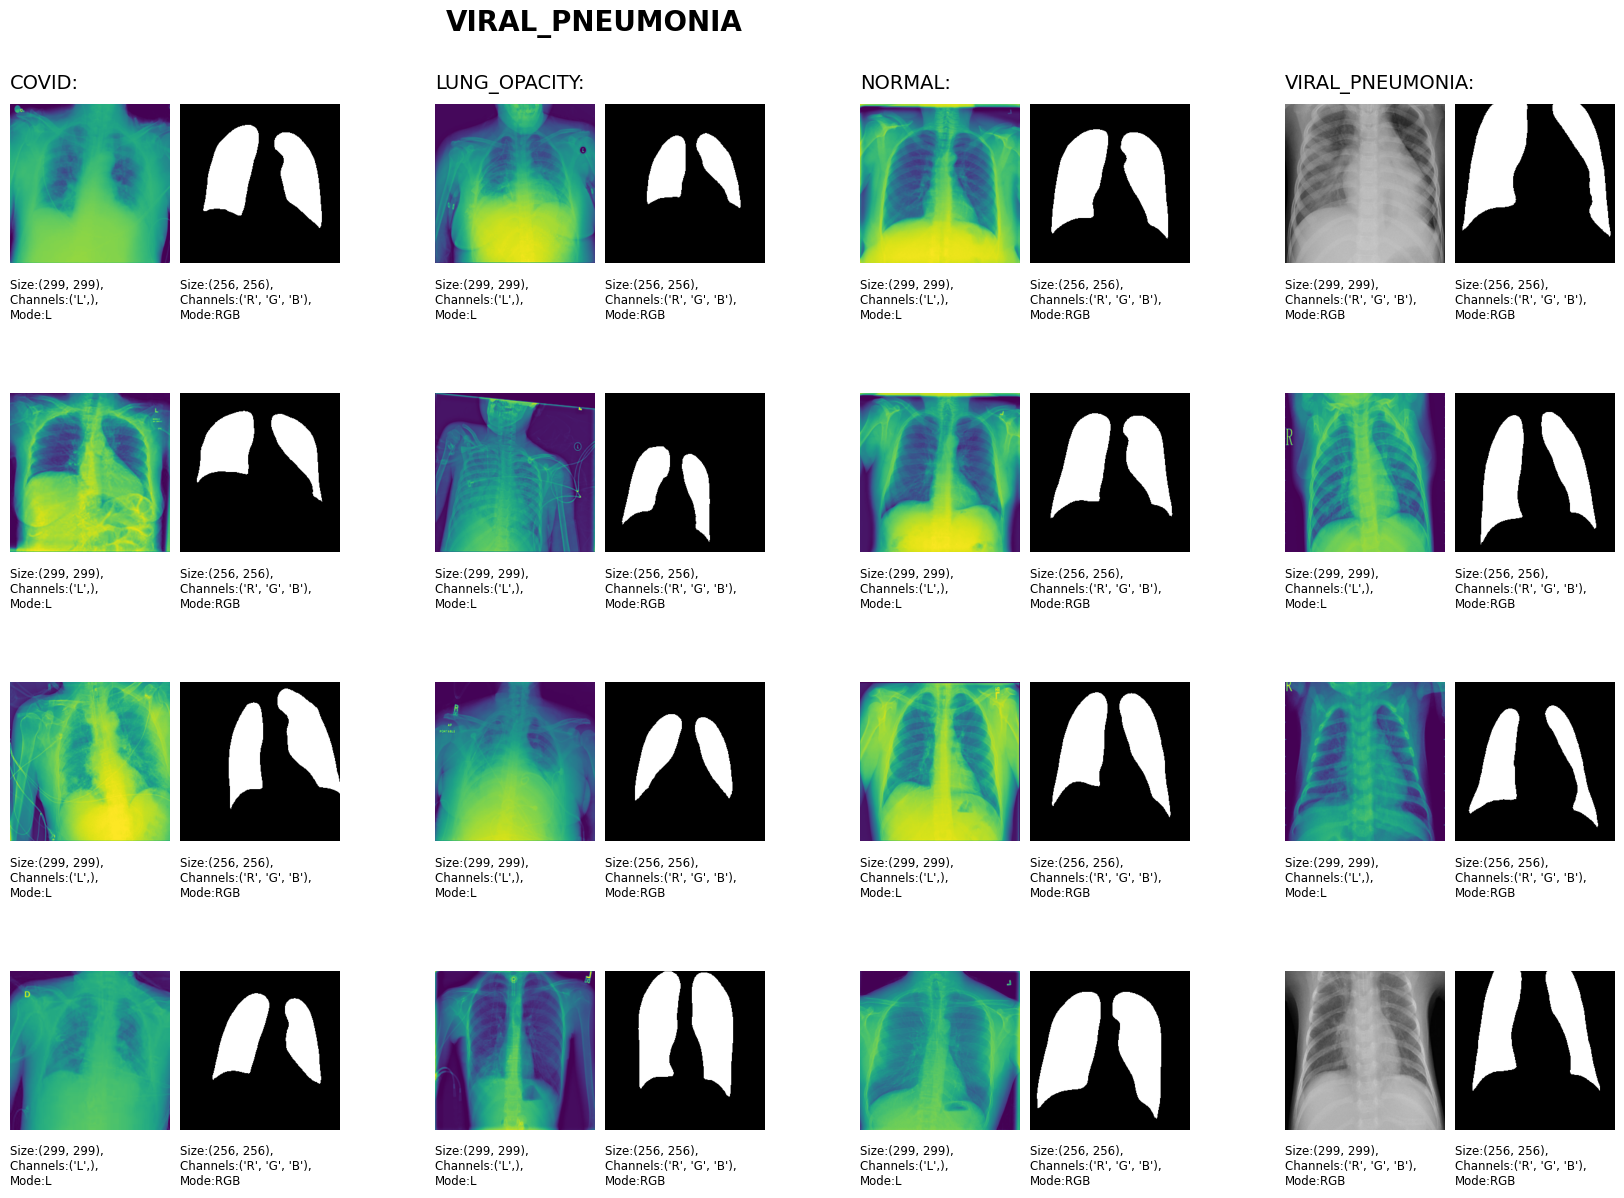

In [8]:
""" 
    Visualizing images with their corresponding masks. Used python image processing library 'Pillow' to extract image specifications like image channels, size, and mode.
"""


from PIL import Image

figure = plt.figure(figsize=(17,15),layout=None)
subfigures = figure.subfigures(1,4)


for i,key in enumerate(samples):
    ax = subfigures[i].subplots(4,2)
    subfigures[i].subplots_adjust(wspace=0.07,hspace=0)
    for row,imgs in enumerate(samples[key]):
        for i in range(len(imgs)):
            x_img = Image.open(imgs[i])
            ax[row,i].imshow(x_img)
            ax[row,i].set_title(f'\nSize:{x_img.size}, \nChannels:{x_img.getbands()}, \nMode:{x_img.mode}',y=-0.4, fontsize=8.5,loc='left')
            ax[row,i].axis('off')
    ax[0,0].annotate(f'{key}:', xy=(0,1.1),xycoords='axes fraction',fontsize=14) 
subfigures[i].suptitle(key,fontsize=20,fontweight='semibold',y=0.90)
    

plt.show()

# Pre-processing

### Data pre-processing will happen as part of data pipeline during model training. 
### To get an idea of what the pipeline will do during training, the exact same function calls are used in this section - only for demonstration purposes.

In [9]:
"""
    Defining global variables:
    1. IMAGE_HEIGHT,IMAGE_WIDTH - target image height and width for U-Net model input
    2. IMAGE_CHANNELS - 1 channel i.e. greyscale images for model / memory efficiency, clarity and removing redundant data. 
                        Also in medical diagnostics, value is associated with internsity gradients, edges and textures - rather than from "colour".
    3. RANDOM_STATE -  fixed value to get reproducible results i.e. to reproduce the exact same results across runs, for experimentation purposes.
    4. LEARNING_RATE - a crucial hyperparameter in machine learning / deep learning that that controls the step size for updating model parameters during training 
    5. BATCH_SIZE - number of data samples processed in one go before a model updates its parameters. Tunable parameter for optimal memory utilization.
"""

IMAGE_HEIGHT= 256
IMAGE_WIDTH = 256
IMAGE_CHANNELS = 1
RANDOM_STATE=42
LEARNING_RATE = 0.0005
BATCH_SIZE=128
CALLBACKS = [],
CLASS_NAMES = list(classes.keys())
N_CLASSES = 4

2026-02-04 18:20:37.442611: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


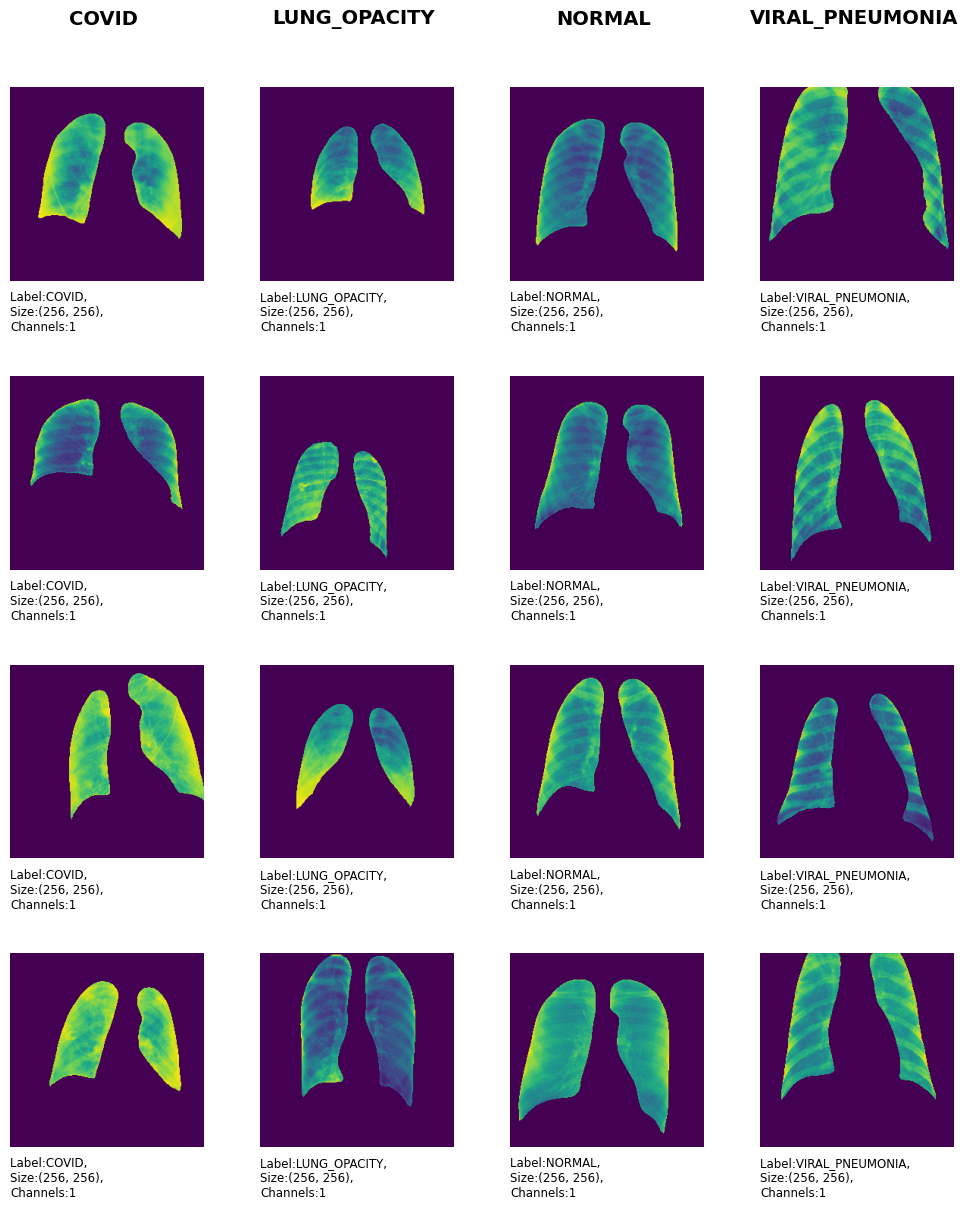

In [10]:
""" 
    The pipeline overlays the X-ray images with their corresponding Masks, and sends this single image to U-Net model for learning. 
    This ensures that the model focuses only on the relevant regions in the image, thereby genaralizing faster.
    Here, we visualize the overlaid images using the same sample images as before.

"""

figure = plt.figure(figsize=(10,15),layout=None)
subfigures = figure.subfigures(1,4)

for i,key in enumerate(classes):
    ax = subfigures[i].subplots(4,1)
    subfigures[i].subplots_adjust(wspace=0.07,hspace=0)
    for j,imgs in enumerate(samples[key]):
        x, m = [f for f in imgs]
        x,m,_ = preprocess_data_pipeline([x,m],key)
        ov,label = process_data_pipeline(x,m,key)
        img = ov.numpy()
        ax[j].imshow(img)
        ax[j].set_title(f'\nLabel:{label}, \nSize:{img.shape[0:2]}, \nChannels:{img.shape[-1]}',y=-0.3, fontsize=8.5,loc='left')
        ax[j].axis('off')     
    subfigures[i].suptitle(key,fontsize=14,fontweight='semibold',y=0.90)


plt.show()


# Preparing Train, Validation and Test Datasets

In [11]:
""" 
    Segregating the X-rays and Masks in separate lists, while maintaining their corresponding mapping to Labels (also in a separate list)
"""

dict = get_data(classes)
xrays, masks, labels = prepare_dataset(dict)

In [12]:
# Encoding Labels in binary vectors

ohe_labels = one_hot_encoding(labels)
ohe_labels = np.float16(ohe_labels)

display_unique_labels(ohe_labels,classes)

LABELS:  (21165, 4)
Vector [0. 0. 0. 1.] corresponds to Class Index: 3 and original label as VIRAL_PNEUMONIA
Vector [0. 0. 1. 0.] corresponds to Class Index: 2 and original label as NORMAL
Vector [0. 1. 0. 0.] corresponds to Class Index: 1 and original label as LUNG_OPACITY
Vector [1. 0. 0. 0.] corresponds to Class Index: 0 and original label as COVID


In [13]:
# Splitting into Train, Validation and Test sets

from sklearn.model_selection import train_test_split

X_train, X_rem, M_trian, M_rem, y_train,y_rem = train_test_split(xrays,masks,ohe_labels,test_size=0.3,stratify=ohe_labels,random_state=RANDOM_STATE)

X_val, X_test, M_val, M_test, y_val, y_test = train_test_split(X_rem, M_rem, y_rem, test_size=0.5,stratify=y_rem,random_state=RANDOM_STATE )

print(' \nThe number of samples in each split are:')
print('\n - Train dataset size: ',len(X_train))
print('\n - Validation dataset size: ',len(X_val))
print('\n - Test dataset size: ',len(X_test))

 
The number of samples in each split are:

 - Train dataset size:  14815

 - Validation dataset size:  3175

 - Test dataset size:  3175


In [14]:
# Creating datasets for Training, Validation and Testing

train_ds = create_ds(X_train,M_trian,y_train)
val_ds = create_ds(X_val, M_val, y_val)
test_ds = create_ds(X_test, M_test, y_test)

vec_list = [l for _,l in  train_ds.take(64).as_numpy_iterator()]         # verifying the dataset shuffling 

print('As seen below, after splitting and shuffling the dataset, Train dataset contain samples from all classes:\n')
display_unique_labels(vec_list,classes)


Creating dataset ...
The tensor specifications for 2 features "X-rays & Masks" and 1 target variable "Labels" are: 
 ((TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.string, name=None)), TensorSpec(shape=(4,), dtype=tf.float16, name=None))
(TensorSpec(shape=(256, 256, 1), dtype=tf.float16, name=None),
 TensorSpec(shape=(4,), dtype=tf.float16, name=None))

The tensor specifications after pre-processing: 
 (TensorSpec(shape=(256, 256, 1), dtype=tf.float16, name=None), TensorSpec(shape=(4,), dtype=tf.float16, name=None)) 

Creating dataset ...
The tensor specifications for 2 features "X-rays & Masks" and 1 target variable "Labels" are: 
 ((TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.string, name=None)), TensorSpec(shape=(4,), dtype=tf.float16, name=None))
(TensorSpec(shape=(256, 256, 1), dtype=tf.float16, name=None),
 TensorSpec(shape=(4,), dtype=tf.float16, name=None))

The tensor specifications after pre-processing: 
 

2026-02-04 18:20:38.250925: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
# Batching only train and validation datasets since its not necessary for test set.

train_ds = batch_dataset(train_ds,BATCH_SIZE,PROJ_DIR)
val_ds = batch_dataset(val_ds,BATCH_SIZE,PROJ_DIR)

# Build U-NET Model

In [16]:
l2_regularizer = tf.keras.regularizers.L2(1e-5)

input = tf.keras.layers.Input(shape=(IMAGE_HEIGHT,IMAGE_WIDTH,IMAGE_CHANNELS))

# building encoder
conv1, pool = build_encoder(input,64)
conv2, pool = build_encoder(pool,128)
conv3, pool = build_encoder(pool,256)

# bottleneck layer
base_layer = conv_block(pool,512)

# building decoder
x = build_decoder(base_layer,256,conv3)
x = build_decoder(x,128,conv2)
x = build_decoder(x,64,conv1)


gap = tf.keras.layers.GlobalAveragePooling2D()(x)

output = tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=l2_regularizer)(gap)
output = tf.keras.layers.Dense(4,activation='softmax',kernel_regularizer=l2_regularizer)(output)


model = tf.keras.models.Model(inputs=input,outputs=[output])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     16,448 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     32,896 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     65,664 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    131,328 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    262,400 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    524,800 │ max_pooling2d_2[

 Total params: 3,845,572 (14.67 MB)

 Trainable params: 3,842,756 (14.66 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [17]:
import gc
tf.keras.backend.clear_session()
gc.collect()

monitor_metrics = ['accuracy',
                   tf.keras.metrics.AUC(curve='PR',name='auc')
                   ]

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss=tf.keras.losses.CategoricalFocalCrossentropy(),                  # Loss function chosen to handle class imbalance
              metrics=monitor_metrics)

In [18]:

model.fit(train_ds, epochs=50, callbacks=callbacks('model.keras',CALLBACKS,f'{PROJ_DIR}/models/'), validation_data=val_ds)

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5938 - auc: 0.6359 - loss: 0.1351
Epoch 1: val_auc improved from None to 0.32801, saving model to /Users/samy/uttara/pneumonia_detection/models//auc/model.keras

Epoch 1: finished saving model to /Users/samy/uttara/pneumonia_detection/models//auc/model.keras

Epoch 1: val_loss improved from None to 0.53696, saving model to /Users/samy/uttara/pneumonia_detection/models//loss/model.keras

Epoch 1: finished saving model to /Users/samy/uttara/pneumonia_detection/models//loss/model.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 800s 7s/step - accuracy: 0.6366 - auc: 0.7005 - loss: 0.1196 - val_accuracy: 0.2718 - val_auc: 0.3280 - val_loss: 0.5370 - learning_rate: 5.0000e-04
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6819 - auc: 0.7583 - loss: 0.0967
Epoch 2: val_auc did not improve from 0.32801

Epoch 2: val_loss did not improve from 0.53696
115/115 ━━━━━━━━━━━━━━━━━━━━ 744s 6s/step - accuracy: 0.6948 - auc: 0.7714 -


 Best epoch:  30

 Train Loss:  0.015349737368524075

 Train accuracy:  0.944497287273407

 Validation Loss:  0.03208271786570549

 Validation accuracy:  0.8841145634651184


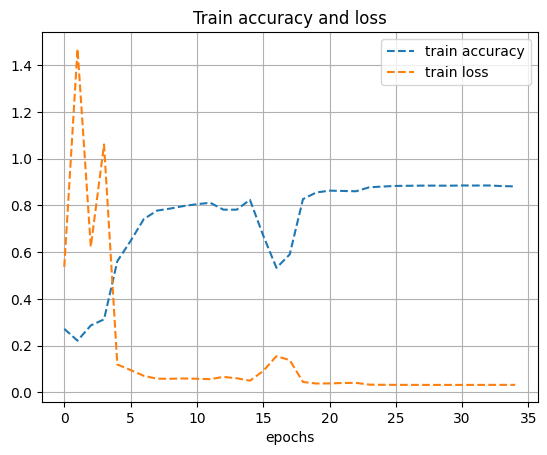

In [19]:
def get_train_metrics(model):

    # Function call to get train metrics corresponding to the epoch with lowest 'val_loss'

    best_epoch = np.argmin(model.history.history['val_loss'])
    train_loss = model.history.history['loss'][best_epoch]
    train_accuracy = model.history.history['accuracy'][best_epoch]
    val_loss = model.history.history['val_loss'][best_epoch]
    val_accuracy = model.history.history['val_accuracy'][best_epoch]

    
    print('\n Best epoch: ', best_epoch+1)
    print('\n Train Loss: ', train_loss)
    print('\n Train accuracy: ', train_accuracy)
    print('\n Validation Loss: ', val_loss)
    print('\n Validation accuracy: ', val_accuracy)

    # Plotting graphs
    train_loss_values = model.history.history['val_loss']
    train_accuracy_values = model.history.history['val_accuracy']

    plt.plot(train_accuracy_values, label='train accuracy', linestyle="--")
    plt.plot(train_loss_values, label='train loss', linestyle="--")
    plt.xlabel('epochs')
    plt.grid()
    plt.title(f'Train accuracy and loss')
    plt.legend()

get_train_metrics(model)